# ETS MARL — Multi-Agent RL for EU Emissions Trading

**Technology-Specific Energy Mix | Real CapEx | Construction Queues | PPO**

This notebook is a testing playground for the ETS MARL simulation.
It clones the repository, installs dependencies, runs tests, trains agents,
and visualizes results — all within Google Colab.

---

### Model Overview
- **4 agents** representing European electricity utilities (10 TWh/year each)
- **5 technologies**: Coal, Gas CCGT, Onshore Wind, Offshore Wind, Solar PV
- **Real-data-grounded** CapEx (IRENA 2024), emission factors (IPCC AR5), deployment delays
- **EU ETS mechanics**: uniform-price auction, MSR, LRF (Fit for 55), 100% auctioning
- **PPO agents** with two-phase decisions (auction + secondary market)
- **Greening-only** constraint: agents can only add renewables, fossil can only decrease

## 1. Setup — Clone Repository & Install Dependencies

In [1]:
# Clone the repository (update URL to your repo)
!git clone https://github.com/DJH961/Thesis-Energy-Auction.git 2>/dev/null || echo 'Repo already cloned'

import os
os.chdir('Thesis-Energy-Auction/ets_marl ppo')
print(f'Working directory: {os.getcwd()}')

Working directory: /content/Thesis-Energy-Auction/ets_marl ppo


In [2]:
# Install dependencies
!pip install -q gymnasium numpy torch pyyaml pandas matplotlib seaborn pytest numpy-groupies

# Verify GPU availability
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 4.8 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Run Tests — Verify Everything Works

In [3]:
!python -m pytest tests/ -v

============================= test session starts ==============================
platform linux -- Python 3.12.12, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/Thesis-Energy-Auction/ets_marl ppo
configfile: pyproject.toml
plugins: typeguard-4.5.1, anyio-4.12.1, langsmith-0.7.7
collected 38 items                                                             

tests/test_cap_schedule.py::test_cap_year_0 PASSED                       [  2%]
tests/test_cap_schedule.py::test_cap_year_1_lrf_phase1 PASSED            [  5%]
tests/test_cap_schedule.py::test_cap_year_5_switches_to_phase2 PASSED    [  7%]
tests/test_cap_schedule.py::test_cap_strictly_decreasing PASSED          [ 10%]
tests/test_cap_schedule.py::test_cap_year_10 PASSED                      [ 13%]
tests/test_cap_schedule.py::test_msr_no_adjustment_within_band PASSED    [ 15%]
tests/test_cap_schedule.py::test_msr_withhold_when_tnac_high PASSED      [ 18%]
tests/test_cap_schedule.py::test_msr_

## 3. Explore the Environment

In [4]:
import sys
sys.path.insert(0, '.')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.environment.ets_environment import ETSEnvironment
from src.environment.company import TECH_NAMES

with open('configs/default.yaml') as f:
    config = yaml.safe_load(f)

env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset()

print('=== Environment Summary ===')
print(f'Agents: {env.n_agents}')
print(f'Years: {env.n_years}')
print(f'Technologies: {TECH_NAMES}')
print(f'Phase 1 obs dim: {obs1.shape[1]}')
print(f'Initial cap: {env.cap_schedule.get_cap(0):.2f} Mt')
print()

tech_names = config['technologies']['names']
for i, c in enumerate(env.companies):
    mix_str = ' | '.join([f'{tech_names[t]}: {c.mix[t]*100:.0f}%' for t in range(5)])
    print(f'A{i+1}: {mix_str}')
    print(f'     Emissions: {c.compute_emissions():.2f} Mt | '
          f'Green: {c.green_frac*100:.0f}% | '
          f'Op. Cost: {c.compute_operational_cost():.0f} M€/yr | '
          f'Avg EF: {c.weighted_emission_factor:.3f} tCO2/MWh')

=== Environment Summary ===
Agents: 4
Years: 12
Technologies: ['coal', 'gas', 'onshore_wind', 'offshore_wind', 'solar']
Phase 1 obs dim: 26
Initial cap: 9.10 Mt

A1: coal: 40% | gas: 40% | onshore_wind: 10% | offshore_wind: 5% | solar: 5%
     Emissions: 5.28 Mt | Green: 20% | Op. Cost: 554 M€/yr | Avg EF: 0.528 tCO2/MWh
A2: coal: 15% | gas: 45% | onshore_wind: 20% | offshore_wind: 10% | solar: 10%
     Emissions: 3.52 Mt | Green: 40% | Op. Cost: 446 M€/yr | Avg EF: 0.352 tCO2/MWh
A3: coal: 5% | gas: 25% | onshore_wind: 35% | offshore_wind: 20% | solar: 15%
     Emissions: 1.77 Mt | Green: 70% | Op. Cost: 342 M€/yr | Avg EF: 0.177 tCO2/MWh
A4: coal: 0% | gas: 10% | onshore_wind: 30% | offshore_wind: 35% | solar: 25%
     Emissions: 0.69 Mt | Green: 90% | Op. Cost: 296 M€/yr | Avg EF: 0.069 tCO2/MWh


## 4. Run a Random-Policy Episode (Baseline)

In [5]:
env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset(seed=42)
n_agents = env.n_agents
rng = np.random.default_rng(42)

year_data = []

for year in range(config['simulation']['n_years']):
    # Random auction actions
    auction_actions = rng.uniform(
        [20.0, 0.0, 0.0, -1.0, -1.0, -1.0],
        [200.0, 5.0, 0.05, 1.0, 1.0, 1.0],
        size=(n_agents, 6)
    ).astype(np.float32)

    obs2, _ = env.step_auction(auction_actions)

    # Random secondary actions
    secondary_actions = rng.uniform(
        [0.5, -5.0], [2.0, 5.0], size=(n_agents, 2)
    ).astype(np.float32)

    obs1, rewards, terminated, _, info = env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price']}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        row[f'reward_A{i+1}'] = rewards[i]
    year_data.append(row)

    if terminated:
        break

df = pd.DataFrame(year_data)
print(df[['year', 'cap', 'price']].to_string(index=False))

 year      cap      price
    0 9.100000 157.005142
    1 8.708700  60.843681
    2 8.334226  72.846878
    3 7.975854  51.819099
    4 7.624917  79.682419
    5 7.289420 169.362152
    6 6.968686  55.358238
    7 6.662064 104.128685
    8 6.368933  75.860245
    9 6.088700 171.843491
   10 5.820797 184.942642
   11 5.564682 138.415390


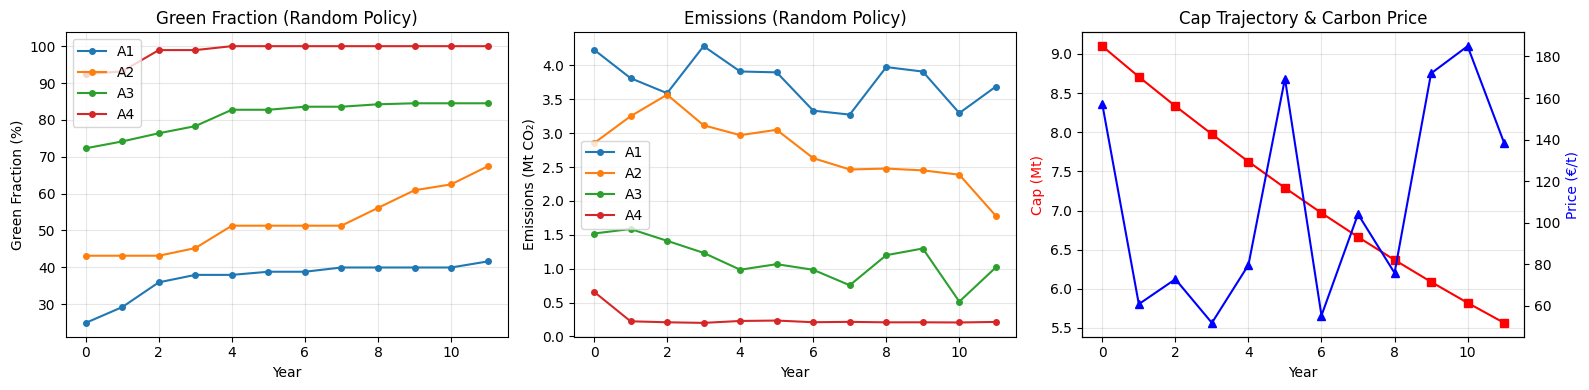

In [6]:
# Plot: Green fraction evolution (random policy)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Green fracs
ax = axes[0]
for i in range(n_agents):
    ax.plot(df['year'], df[f'green_A{i+1}'] * 100, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Green Fraction (%)')
ax.set_title('Green Fraction (Random Policy)')
ax.legend()
ax.grid(True, alpha=0.3)

# Emissions
ax = axes[1]
for i in range(n_agents):
    ax.plot(df['year'], df[f'emissions_A{i+1}'], label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (Mt CO₂)')
ax.set_title('Emissions (Random Policy)')
ax.legend()
ax.grid(True, alpha=0.3)

# Cap & Price
ax = axes[2]
ax.plot(df['year'], df['cap'], label='Cap (Mt)', marker='s', color='red')
ax2 = ax.twinx()
ax2.plot(df['year'], df['price'], label='Price (€/t)', marker='^', color='blue')
ax.set_xlabel('Year')
ax.set_ylabel('Cap (Mt)', color='red')
ax2.set_ylabel('Price (€/t)', color='blue')
ax.set_title('Cap Trajectory & Carbon Price')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Train PPO Agents (Short Run)

In [7]:
from scripts.train import train_one_seed

# Override for quick Colab run (reduce episodes)
train_config = config.copy()
train_config['simulation'] = dict(config['simulation'])
train_config['simulation']['n_episodes'] = 500  # Increase for better results
train_config['logging'] = dict(config['logging'])
train_config['logging']['log_interval'] = 50
train_config['logging']['save_interval'] = 100

train_one_seed(train_config, seed=42)


Training — seed 42, 4 agents, PPO, two-phase
Technology-specific mix | Real CapEx | Construction queues
P1-P8 roadmap improvements active
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Ep     0 │ price=  93.6  cap=    6  TNAC=     9 │ sec_p=100.3  sec_vol=   13.2  match=67% │ ent=0.0500  shaping=1.000 [cyc=A1]
         BankSt   Alloc   Emiss  SecNet    Hold Short/yr    Pen/yr  Green  ΔGreen   Bid  │   EpRew  EpShort     EpPen   aLoss   cLoss
  A1*:     0.5     2.5     2.3    +0.0     0.6     0.00       0.0  53.2%   +0.0% 141.1  │   -4.04     9.70     180.2 -0.0190  4.4031
  A2 :     0.0     0.7     1.6    -0.7     0.0     1.61     160.8  66.1%   +3.0% 105.5  │   -4.60    14.65    1041.8    n/a     n/a 
  A3 :     6.9     1.2     0.2    +0.7     8.6     0.00       0.0  97.8%   +0.0% 132.8  │   -2.37     0.00       0.0    n/a     n/a 
  A4 :     1.4     0.0     0.2    +0.0     1.1     0.00       0.0 100.0%   +0.0%  93.0  

## 6. Analyze Training Results

In [15]:
# Load training logs
ep_df = pd.read_csv('results/training_log_s42.csv')
yr_df = pd.read_csv('results/year_log_s42.csv')

print(f'Training episodes: {len(ep_df)}')
print(f'Year-level records: {len(yr_df)}')
ep_df.tail()

Training episodes: 10100
Year-level records: 121200


,episode,clearing_price_last,cap_last,entropy_coef,shaping_weight,entropy_decay_triggered,active_agent,reward_A1,green_frac_A1,delta_green_A1,...,delta_green_A4,penalty_A4,shortfall_A4,queue_size_A4,actor_loss_A4,critic_loss_A4,bid_price_A4,secondary_volume,secondary_avg_price,secondary_match_rate
10095,10095,200.000000,5.564682,0.05,0.0,0,3,-21.6710,0.2506,0.05062,...,0.05003,479.864291,5.082658,1.75,-0.055650,1.441510,20.0,0.0000,0.00,0.000
10096,10096,200.000000,5.564682,0.05,0.0,0,0,-21.2793,0.2559,0.05585,...,0.03915,121.209886,1.433298,1.83,0.000000,0.000000,20.0,3.8584,255.71,0.083
10097,10097,69.813385,5.564682,0.05,0.0,0,1,-21.7203,0.2458,0.04583,...,0.05009,432.858717,4.875143,0.83,0.000000,0.000000,20.0,0.0000,0.00,0.000
10098,10098,200.000000,5.564682,0.05,0.0,0,2,-21.7075,0.2596,0.05957,...,0.05016,384.261403,4.232857,1.17,0.000000,0.000000,20.0,0.0000,0.00,0.000
10099,10099,200.000000,5.564682,0.05,0.0,0,3,-22.9568,0.2439,0.04388,...,0.04354,484.901732,5.626962,1.00,-0.053554,0.636674,20.0,0.0000,0.00,0.000


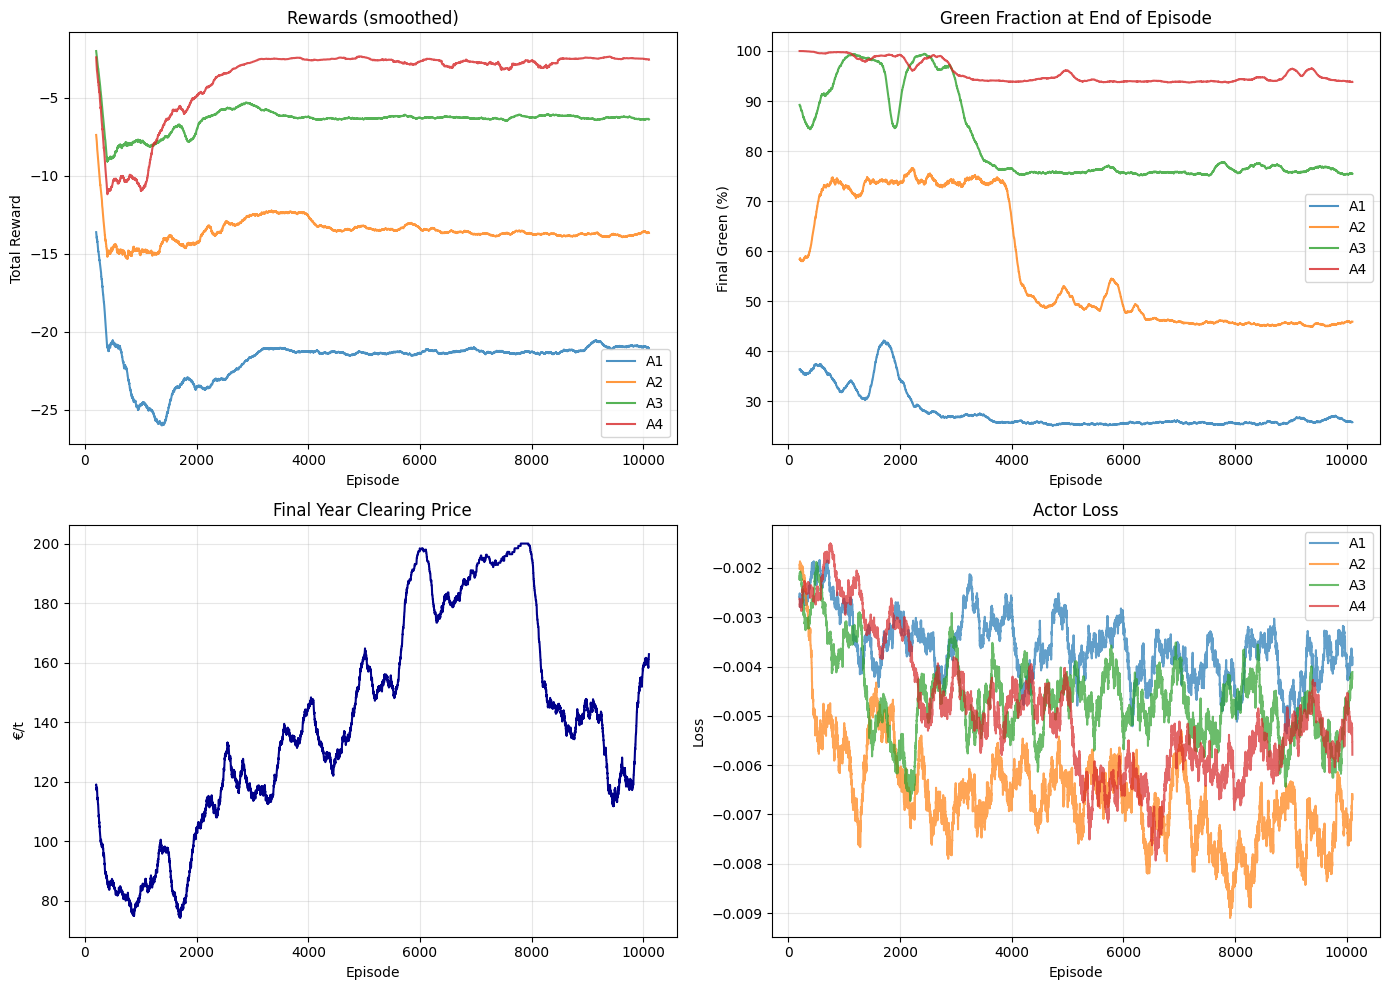

In [16]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
n_agents = config['companies']['n_agents']
window = max(1, len(ep_df) // 50)  # smoothing window

# 1. Rewards
ax = axes[0, 0]
for i in range(n_agents):
    col = f'reward_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean(), label=f'A{i+1}', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('Rewards (smoothed)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Green fractions
ax = axes[0, 1]
for i in range(n_agents):
    col = f'green_frac_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean() * 100, label=f'A{i+1}', alpha=0.8)
ax.set_xlabel('Episode')
ax.set_ylabel('Final Green (%)')
ax.set_title('Green Fraction at End of Episode')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Clearing price
ax = axes[1, 0]
ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(window).mean(), color='darkblue')
ax.set_xlabel('Episode')
ax.set_ylabel('€/t')
ax.set_title('Final Year Clearing Price')
ax.grid(True, alpha=0.3)

# 4. Actor loss
ax = axes[1, 1]
for i in range(n_agents):
    col = f'actor_loss_A{i+1}'
    ax.plot(ep_df['episode'], ep_df[col].rolling(window).mean(), label=f'A{i+1}', alpha=0.7)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title('Actor Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

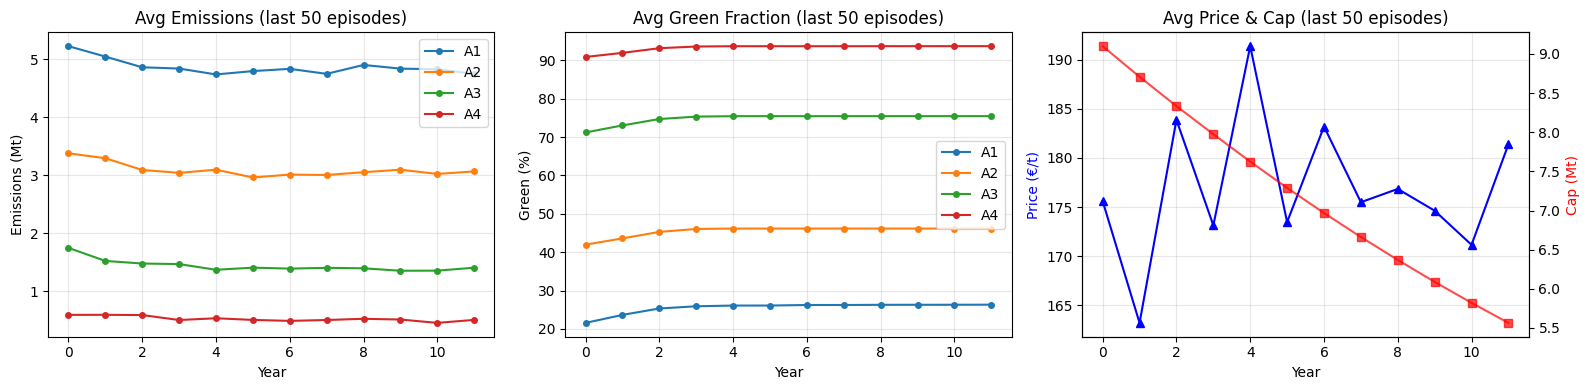

In [17]:
# Year-level analysis: last 50 episodes
last_eps = yr_df['episode'].unique()[-50:]
recent = yr_df[yr_df['episode'].isin(last_eps)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Emissions by year (averaged over recent episodes)
ax = axes[0]
for i in range(n_agents):
    avg = recent.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(avg.index, avg.values, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Emissions (Mt)')
ax.set_title('Avg Emissions (last 50 episodes)')
ax.legend()
ax.grid(True, alpha=0.3)

# Green frac by year
ax = axes[1]
for i in range(n_agents):
    avg = recent.groupby('year')[f'green_frac_A{i+1}'].mean()
    ax.plot(avg.index, avg.values * 100, label=f'A{i+1}', marker='o', markersize=4)
ax.set_xlabel('Year')
ax.set_ylabel('Green (%)')
ax.set_title('Avg Green Fraction (last 50 episodes)')
ax.legend()
ax.grid(True, alpha=0.3)

# Carbon price trajectory
ax = axes[2]
avg_price = recent.groupby('year')['clearing_price'].mean()
avg_cap = recent.groupby('year')['cap'].mean()
ax.plot(avg_price.index, avg_price.values, label='Clearing Price', marker='^', color='blue')
ax2 = ax.twinx()
ax2.plot(avg_cap.index, avg_cap.values, label='Cap', marker='s', color='red', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Price (€/t)', color='blue')
ax2.set_ylabel('Cap (Mt)', color='red')
ax.set_title('Avg Price & Cap (last 50 episodes)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6b. P5–P8 Stochastic Deviation Analysis

Visualise the **random noise** introduced by each mechanism across training:
- **P5** — Emission demand shocks (ε ~ correlated normal, σ=7%)
- **P6** — Green capacity-factor noise + project cancellations
- **P8** — Banking holding costs (penalty for excess allowance hoarding)

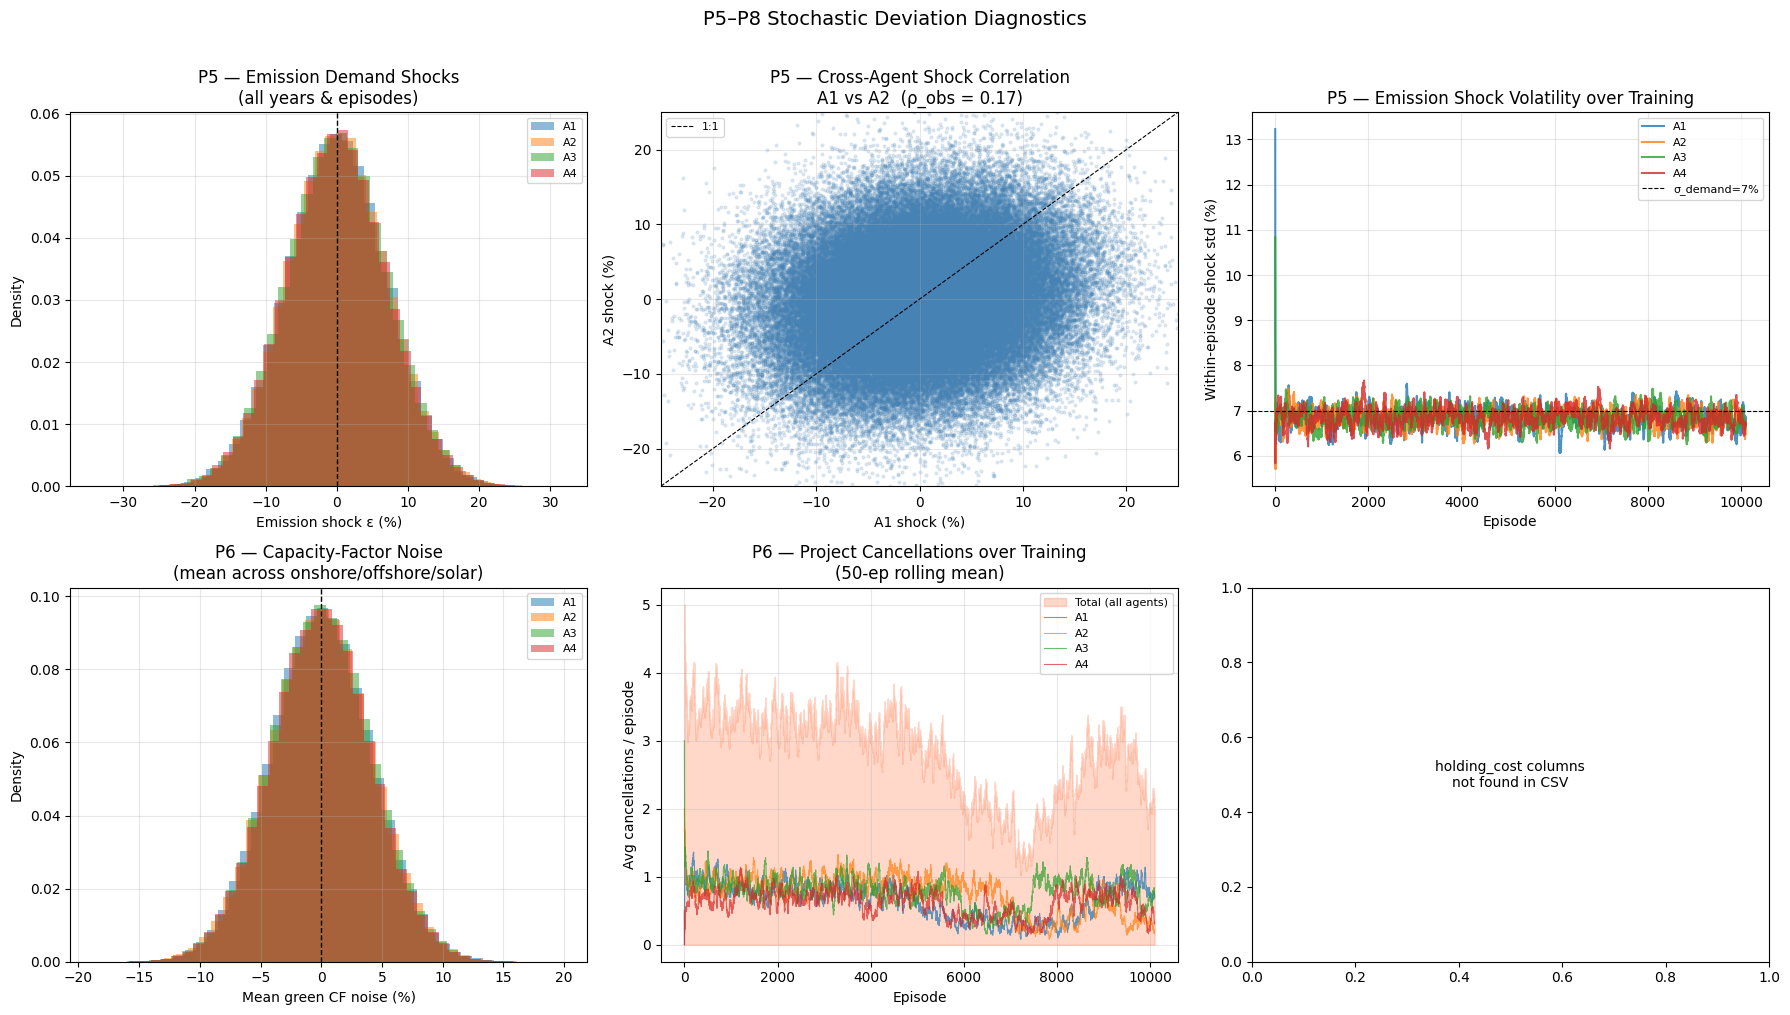


─── P5/P6/P8 deviation summary (all training data) ───
   ε_mean (%) ε_std (%) CF_noise_std (%) cancels_total holdcost_sum (M€)
A1      0.021     7.004            4.126          6607               n/a
A2      0.025     7.005            4.129          7570               n/a
A3      0.013     6.999            4.128          7881               n/a
A4      0.001     7.002            4.123          6273               n/a


In [18]:
# ── P5/P6/P8 stochastic deviation analysis ─────────────────────────────────
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']
tech_names = config['technologies']['names']

# Check which deviation columns exist (only present after a training run
# that includes the P5-P8 instrumentation)
shock_cols    = [f'emission_shock_A{i+1}' for i in range(n_agents)]
cf_cols       = [f'cf_shock_A{i+1}'       for i in range(n_agents)]
cancel_cols   = [f'cancellation_A{i+1}'   for i in range(n_agents)]
hcost_cols    = [f'holding_cost_A{i+1}'   for i in range(n_agents)]

has_deviations = all(c in yr_df.columns for c in shock_cols)
if not has_deviations:
    print('Deviation columns not found — re-run training with the updated train.py')
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # ── 1. P5 emission shock distribution (all agents, all years) ────────────
    ax = axes[0, 0]
    for i in range(n_agents):
        vals = yr_df[shock_cols[i]] * 100   # convert to %
        ax.hist(vals, bins=40, alpha=0.5, label=f'A{i+1}', density=True)
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Emission shock ε (%)')
    ax.set_ylabel('Density')
    ax.set_title('P5 — Emission Demand Shocks\n(all years & episodes)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── 2. P5 shock correlation check (A1 vs A2 — should be positively correlated) ──
    ax = axes[0, 1]
    ax.scatter(yr_df[shock_cols[0]] * 100, yr_df[shock_cols[1]] * 100,
               alpha=0.15, s=4, color='steelblue')
    lims = [-25, 25]
    ax.plot(lims, lims, 'k--', lw=0.8, label='1:1')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('A1 shock (%)')
    ax.set_ylabel('A2 shock (%)')
    corr = yr_df[shock_cols[0]].corr(yr_df[shock_cols[1]])
    ax.set_title(f'P5 — Cross-Agent Shock Correlation\nA1 vs A2  (ρ_obs = {corr:.2f})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── 3. P5 shock magnitude over training (rolling std per agent) ──────────
    ax = axes[0, 2]
    ep_shock_std = (
        yr_df.groupby('episode')[[*shock_cols]]
        .std()
        .rolling(50, min_periods=1)
        .mean()
    )
    for i in range(n_agents):
        ax.plot(ep_shock_std.index, ep_shock_std[shock_cols[i]] * 100,
                label=f'A{i+1}', alpha=0.8)
    ax.axhline(7.0, color='k', ls='--', lw=0.8, label='σ_demand=7%')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Within-episode shock std (%)')
    ax.set_title('P5 — Emission Shock Volatility over Training')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── 4. P6 CF noise distribution (green techs averaged) ───────────────────
    ax = axes[1, 0]
    for i in range(n_agents):
        vals = yr_df[cf_cols[i]] * 100
        ax.hist(vals, bins=40, alpha=0.5, label=f'A{i+1}', density=True)
    ax.axvline(0, color='k', lw=1, ls='--')
    ax.set_xlabel('Mean green CF noise (%)')
    ax.set_ylabel('Density')
    ax.set_title('P6 — Capacity-Factor Noise\n(mean across onshore/offshore/solar)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── 5. P6 project cancellations over training ─────────────────────────────
    ax = axes[1, 1]
    ep_cancels = (
        yr_df.groupby('episode')[[*cancel_cols]]
        .sum()
        .rolling(50, min_periods=1)
        .mean()
    )
    ep_cancels['total'] = ep_cancels[cancel_cols].sum(axis=1)
    ax.fill_between(ep_cancels.index, ep_cancels['total'],
                    alpha=0.3, color='coral', label='Total (all agents)')
    for i in range(n_agents):
        ax.plot(ep_cancels.index, ep_cancels[cancel_cols[i]],
                lw=0.8, label=f'A{i+1}', alpha=0.7)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Avg cancellations / episode')
    ax.set_title('P6 — Project Cancellations over Training\n(50-ep rolling mean)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── 6. P8 holding cost over training ─────────────────────────────────────
    ax = axes[1, 2]
    has_hcost = all(c in yr_df.columns for c in hcost_cols)
    if has_hcost:
        ep_hcost = (
            yr_df.groupby('episode')[[*hcost_cols]]
            .sum()
            .rolling(50, min_periods=1)
            .mean()
        )
        for i in range(n_agents):
            ax.plot(ep_hcost.index, ep_hcost[hcost_cols[i]],
                    label=f'A{i+1}', alpha=0.8)
        ax.set_xlabel('Episode')
        ax.set_ylabel('Holding cost / episode (M€)')
        ax.set_title('P8 — Excess-Bank Holding Costs over Training\n(50-ep rolling mean)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'holding_cost columns\nnot found in CSV',
                ha='center', va='center', transform=ax.transAxes)

    plt.suptitle('P5–P8 Stochastic Deviation Diagnostics', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    # Summary statistics table
    print('\n─── P5/P6/P8 deviation summary (all training data) ───')
    summary = {}
    for i in range(n_agents):
        summary[f'A{i+1}'] = {
            'ε_mean (%)':    round(yr_df[shock_cols[i]].mean()  * 100, 3),
            'ε_std (%)':     round(yr_df[shock_cols[i]].std()   * 100, 3),
            'CF_noise_std (%)': round(yr_df[cf_cols[i]].std()   * 100, 3),
            'cancels_total': int(yr_df[cancel_cols[i]].sum()),
            'holdcost_sum (M€)': round(yr_df[hcost_cols[i]].sum(), 2) if has_hcost else 'n/a',
        }
    print(pd.DataFrame(summary).T.to_string())

## 6c. Year-by-Year Trajectory Analysis (last N episodes)

Slices the **year_log** to show how behaviour evolves *within* an episode across years 0–9.
Uses the last 100 episodes so the plots represent mature policy behaviour, not early exploration.

Four panels per row:
1. **Allocation vs Emissions** — over-allocation → surplus banking; under-allocation → shortfall risk  
2. **Banking** — bank_start and bank_end per year to see carry-forward dynamics  
3. **Secondary market net** — positive = net seller (revenue), negative = net buyer (cost)  
4. **Compliance surplus / shortfall** — pre-compliance headroom; negative → penalty risk

In [ ]:
# ── 6c: Year-by-year trajectory analysis ──────────────────────────────────
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']

N_LAST = 100  # episodes to average over
last_eps = yr_df['episode'].unique()[-N_LAST:]
recent = yr_df[yr_df['episode'].isin(last_eps)].copy()

# Check which new columns are present (added by updated train.py)
has_bank_end   = 'bank_end_A1'            in recent.columns
has_sec_net    = 'secondary_net_A1'       in recent.columns
has_surplus    = 'compliance_surplus_A1'  in recent.columns
has_auc_cost   = 'auction_cost_A1'        in recent.columns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
agent_colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:n_agents]

# ── Panel 1: Allocation vs Emissions ──────────────────────────────────────
ax = axes[0, 0]
for i in range(n_agents):
    alloc_avg = recent.groupby('year')[f'alloc_A{i+1}'].mean()
    emiss_avg = recent.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(alloc_avg.index, alloc_avg.values,
            color=agent_colors[i], lw=2, label=f'A{i+1} alloc')
    ax.plot(emiss_avg.index, emiss_avg.values,
            color=agent_colors[i], lw=1.5, ls='--', alpha=0.7, label=f'A{i+1} emiss')
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Mt CO₂')
ax.set_title(f'Allocation vs Emissions\n(avg last {N_LAST} eps)')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 2: Banking dynamics (bank_start and bank_end) ────────────────────
ax = axes[0, 1]
for i in range(n_agents):
    bs = recent.groupby('year')[f'bank_start_A{i+1}'].mean()
    ax.plot(bs.index, bs.values, color=agent_colors[i], lw=2,
            label=f'A{i+1} start')
    if has_bank_end:
        be = recent.groupby('year')[f'bank_end_A{i+1}'].mean()
        ax.plot(be.index, be.values, color=agent_colors[i], lw=1.5, ls=':',
                alpha=0.8, label=f'A{i+1} end')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Banked Allowances (Mt)')
ax.set_title(f'Banking Dynamics (bank_start / bank_end)\n(avg last {N_LAST} eps)')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# ── Panel 3: Secondary market net (positive = net revenue) ────────────────
ax = axes[1, 0]
if has_sec_net:
    for i in range(n_agents):
        avg = recent.groupby('year')[f'secondary_net_A{i+1}'].mean()
        ax.bar(avg.index + i * 0.2, avg.values, width=0.18,
               color=agent_colors[i], alpha=0.75, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Year in Episode')
    ax.set_ylabel('Net secondary P&L (M€)  +ve=revenue')
    ax.set_title(f'Secondary Market Net Revenue by Year\n(avg last {N_LAST} eps)')
    ax.legend(fontsize=7)
else:
    # Fall back to trade_cost
    for i in range(n_agents):
        avg = recent.groupby('year')[f'trade_cost_A{i+1}'].mean()
        ax.plot(avg.index, -avg.values, color=agent_colors[i], lw=1.5,
                label=f'A{i+1}', marker='o', markersize=3)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Year in Episode')
    ax.set_ylabel('−trade_cost (M€)  +ve=revenue')
    ax.set_title(f'Secondary Net (from trade_cost, last {N_LAST} eps)')
    ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# ── Panel 4: Compliance surplus / shortfall ───────────────────────────────
ax = axes[1, 1]
if has_surplus:
    for i in range(n_agents):
        avg = recent.groupby('year')[f'compliance_surplus_A{i+1}'].mean()
        ax.plot(avg.index, avg.values, color=agent_colors[i], lw=2,
                marker='s', markersize=4, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=1.2, ls='--', label='break-even')
else:
    for i in range(n_agents):
        sf = recent.groupby('year')[f'shortfall_A{i+1}'].mean()
        ax.plot(sf.index, -sf.values, color=agent_colors[i], lw=2,
                marker='s', markersize=4, label=f'A{i+1}')
    ax.axhline(0, color='k', lw=1.2, ls='--')
ax.set_xlabel('Year in Episode')
ax.set_ylabel('Surplus Mt  (+ve = safe, −ve = shortfall)')
ax.set_title(f'Compliance Surplus/Shortfall by Year\n(avg last {N_LAST} eps)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Year-by-Year Trajectory (last {N_LAST} episodes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Cost breakdown summary per year (if auction_cost logged) ──────────────
if has_auc_cost:
    print('\n── Average yearly cost breakdown (last 100 eps, all agents combined) ──')
    cols_show = {}
    for i in range(n_agents):
        cols_show[f'A{i+1}_auc(M€)'] = recent.groupby('year')[f'auction_cost_A{i+1}'].mean()
        cols_show[f'A{i+1}_inv(M€)'] = recent.groupby('year')[f'invest_cost_A{i+1}'].mean()
        cols_show[f'A{i+1}_pen(M€)'] = recent.groupby('year')[f'penalty_A{i+1}'].mean()
    print(pd.DataFrame(cols_show).round(2).to_string())


## 6d. Episode Consistency & Variance (ribbon plots)

Shows **mean ± 1 std** bands over the last 100 episodes for key year-level signals.
Wide bands → high variance / unstable policy. Narrow bands → consistent behaviour.

Includes a **price ribbon** (year 0→9 trajectory) and per-agent **green fraction trajectory**.

In [ ]:
# ── 6d: Episode consistency – ribbon plots (mean ± 1σ over last 100 episodes) ──
yr_df = pd.read_csv('results/year_log_s42.csv')
n_agents = config['companies']['n_agents']

N_LAST = 100
last_eps = yr_df['episode'].unique()[-N_LAST:]
recent = yr_df[yr_df['episode'].isin(last_eps)].copy()
years  = sorted(recent['year'].unique())

def ribbon(ax, grp, col, color, label):
    """Plot mean ± 1 std ribbon for `col` grouped by year."""
    mu  = grp[col].mean()
    std = grp[col].std().fillna(0)
    ax.plot(mu.index, mu.values, color=color, lw=2, label=label)
    ax.fill_between(mu.index, mu - std, mu + std,
                    color=color, alpha=0.18)

grp = recent.groupby('year')
agent_colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:n_agents]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# ── 1. Clearing price trajectory ──────────────────────────────────────────
ax = axes[0, 0]
ribbon(ax, grp, 'clearing_price', 'steelblue', 'Clearing Price')
ax.set_xlabel('Year'); ax.set_ylabel('€/t')
ax.set_title('Clearing Price Trajectory\nmean ± 1σ (last 100 eps)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# ── 2. Green fraction per agent ───────────────────────────────────────────
ax = axes[0, 1]
for i in range(n_agents):
    ribbon(ax, grp, f'green_frac_A{i+1}', agent_colors[i], f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Green fraction')
ax.set_title('Green Fraction Trajectory\nmean ± 1σ')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# ── 3. Emissions per agent ────────────────────────────────────────────────
ax = axes[0, 2]
for i in range(n_agents):
    ribbon(ax, grp, f'emissions_A{i+1}', agent_colors[i], f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂')
ax.set_title('Realized Emissions\nmean ± 1σ (P5 shock visible as wide bands)')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# ── 4. Banking (bank_start) per agent ─────────────────────────────────────
ax = axes[1, 0]
for i in range(n_agents):
    ribbon(ax, grp, f'bank_start_A{i+1}', agent_colors[i], f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.set_ylabel('Banked Mt')
ax.set_title('Banking Strategy\nmean ± 1σ')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# ── 5. Reward per agent ───────────────────────────────────────────────────
ax = axes[1, 1]
for i in range(n_agents):
    ribbon(ax, grp, f'reward_A{i+1}', agent_colors[i], f'A{i+1}')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.set_ylabel('Reward')
ax.set_title('Per-Year Reward\nmean ± 1σ')
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# ── 6. P8 holding cost (if logged) / shortfall ────────────────────────────
ax = axes[1, 2]
has_hcost = 'holding_cost_A1' in recent.columns
if has_hcost:
    for i in range(n_agents):
        ribbon(ax, grp, f'holding_cost_A{i+1}', agent_colors[i], f'A{i+1} hold_cost')
    ax.set_ylabel('Holding cost M€')
    ax.set_title('P8 Holding Costs by Year\nmean ± 1σ')
else:
    for i in range(n_agents):
        ribbon(ax, grp, f'shortfall_A{i+1}', agent_colors[i], f'A{i+1}')
    ax.set_ylabel('Shortfall Mt')
    ax.set_title('Shortfall by Year\nmean ± 1σ')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Year'); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

plt.suptitle(f'Episode Consistency & Variance (last {N_LAST} episodes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Variance summary table ────────────────────────────────────────────────
print(f'\n── Year-level variance summary (std across {N_LAST} episodes, mean over years) ──')
var_summary = {}
for i in range(n_agents):
    var_summary[f'A{i+1}'] = {
        'price_std (€/t)':   round(recent.groupby('year')['clearing_price'].std().mean(), 2),
        'green_frac_std':    round(recent.groupby('year')[f'green_frac_A{i+1}'].std().mean(), 4),
        'emissions_std(Mt)': round(recent.groupby('year')[f'emissions_A{i+1}'].std().mean(), 3),
        'bank_std(Mt)':      round(recent.groupby('year')[f'bank_start_A{i+1}'].std().mean(), 3),
        'reward_std':        round(recent.groupby('year')[f'reward_A{i+1}'].std().mean(), 4),
    }
print(pd.DataFrame(var_summary).T.to_string())


## 7. Evaluate Best Agents (Deterministic)

In [19]:
from scripts.train import build_agents

# Load best checkpoints
eval_env = ETSEnvironment(config, seed=0)
eval_agents = build_agents(eval_env, config, seed=0)

ckpt_dir = 'results/checkpoints_s42'
for i, agent in enumerate(eval_agents):
    ckpt_path = os.path.join(ckpt_dir, f'agent_{i}_best.pt')
    if os.path.exists(ckpt_path):
        agent.load(ckpt_path)
        print(f'Loaded agent {i}')
    else:
        print(f'No checkpoint for agent {i} — using untrained policy')

# Run deterministic evaluation
obs1, _ = eval_env.reset(seed=0)
eval_data = []

for year in range(config['simulation']['n_years']):
    auction_actions = np.zeros((n_agents, 6), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_auction_action(obs1[i], deterministic=True)
        auction_actions[i] = action
    obs2, _ = eval_env.step_auction(auction_actions)

    secondary_actions = np.zeros((n_agents, 2), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_secondary_action(obs2[i], deterministic=True)
        secondary_actions[i] = action

    obs1, rewards, terminated, _, info = eval_env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price']}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        for t in range(5):
            row[f'mix_A{i+1}_{tech_names[t]}'] = log['tech_mixes'][i][t]
    eval_data.append(row)
    if terminated:
        break

eval_df = pd.DataFrame(eval_data)
print(eval_df[['year', 'cap', 'price'] + [f'green_A{i+1}' for i in range(n_agents)]].to_string(index=False))

Loaded agent 0
Loaded agent 1
Loaded agent 2
Loaded agent 3
 year      cap     price  green_A1  green_A2  green_A3  green_A4
    0 9.100000 88.279404  0.225409  0.422264  0.737506  0.933114
    1 8.708700 86.488457  0.225409  0.422264  0.737506  0.933114
    2 8.334226 85.987946  0.241282  0.422264  0.737506  0.973923
    3 7.975854 84.916451  0.263344  0.422264  0.810402  1.000000
    4 7.624917 83.937263  0.263344  0.493752  0.838438  1.000000
    5 7.289420 82.862419  0.285295  0.517289  0.838438  1.000000
    6 6.968686 81.612122  0.285295  0.517289  0.838438  1.000000
    7 6.662064 80.564713  0.329378  0.517289  0.866448  1.000000
    8 6.368933 79.361763  0.329378  0.540347  0.879818  1.000000
    9 6.088700 99.221542  0.351349  0.540347  0.879818  1.000000
   10 5.820797 98.673912  0.373456  0.540347  0.892843  1.000000
   11 5.564682 98.602249  0.373456  0.563165  0.905489  1.000000


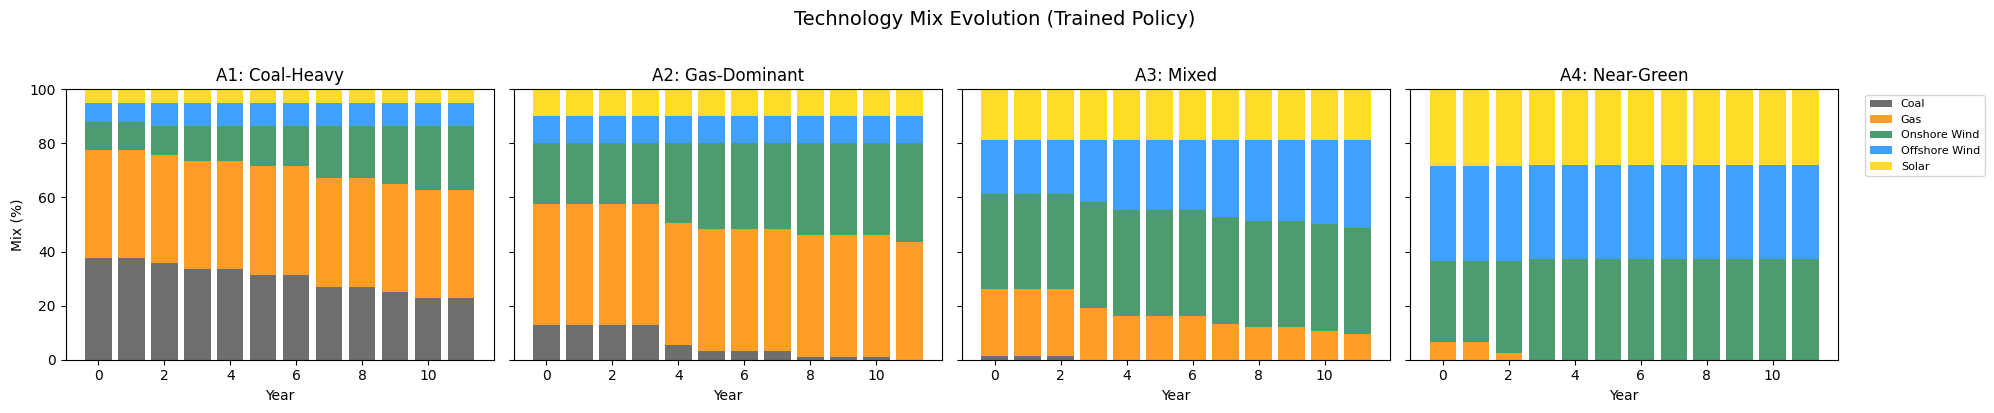

In [20]:
# Technology mix evolution per agent
tech_names = config['technologies']['names']
colors = {'coal': '#555555', 'gas': '#FF8C00', 'onshore_wind': '#2E8B57',
          'offshore_wind': '#1E90FF', 'solar': '#FFD700'}

fig, axes = plt.subplots(1, n_agents, figsize=(5*n_agents, 4), sharey=True)
archetypes = ['Coal-Heavy', 'Gas-Dominant', 'Mixed', 'Near-Green']

for i in range(n_agents):
    ax = axes[i] if n_agents > 1 else axes
    bottom = np.zeros(len(eval_df))
    for t in range(5):
        vals = eval_df[f'mix_A{i+1}_{tech_names[t]}'].values * 100
        ax.bar(eval_df['year'], vals, bottom=bottom,
               label=tech_names[t].replace('_', ' ').title(),
               color=colors[tech_names[t]], alpha=0.85)
        bottom += vals
    ax.set_xlabel('Year')
    if i == 0:
        ax.set_ylabel('Mix (%)')
    ax.set_title(f'A{i+1}: {archetypes[i]}')
    ax.set_ylim(0, 100)
    if i == n_agents - 1:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.suptitle('Technology Mix Evolution (Trained Policy)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Investment Cost Sanity Check

Verify that investment costs match real-world data (action plan §2).

In [13]:
env = ETSEnvironment(config, seed=42)
env.reset()
c = env.companies[0]  # A1: coal-heavy

print('=== Investment Cost Sanity Check ===')
print(f'Company output: {c.output_twh} TWh/year = {c.output_mwh/1e6:.0f} million MWh')
print()

for tech_idx, name in [(2, 'Onshore Wind'), (3, 'Offshore Wind'), (4, 'Solar PV')]:
    frac = 0.03  # 3% of output
    delta_mwh = frac * c.output_mwh
    cf = c.capacity_factors[tech_idx]
    delta_mw = delta_mwh / (cf * 8760)
    cost = c.compute_investment_cost(tech_idx, frac)
    print(f'{name}:')
    print(f'  Shift: {frac*100:.0f}% = {delta_mwh/1e6:.0f} GWh/yr')
    print(f'  New capacity: {delta_mw:.0f} MW (at CF={cf:.0%})')
    print(f'  CapEx: {c.capex[tech_idx]:.0f} €/kW')
    print(f'  Investment cost: {cost:.1f} M€')
    print()

=== Investment Cost Sanity Check ===
Company output: 10.0 TWh/year = 10 million MWh

Onshore Wind:
  Shift: 3% = 0 GWh/yr
  New capacity: 98 MW (at CF=35%)
  CapEx: 1350 €/kW
  Investment cost: 132.7 M€

Offshore Wind:
  Shift: 3% = 0 GWh/yr
  New capacity: 73 MW (at CF=47%)
  CapEx: 3250 €/kW
  Investment cost: 237.7 M€

Solar PV:
  Shift: 3% = 0 GWh/yr
  New capacity: 201 MW (at CF=17%)
  CapEx: 750 €/kW
  Investment cost: 152.6 M€



## 9. Full Training Run (Longer)

Uncomment and run for a more complete training. Takes ~15-30 min on Colab GPU.

In [14]:
# # Full training (uncomment to run)
full_config = config.copy()
full_config['simulation'] = dict(config['simulation'])
full_config['simulation']['n_episodes'] = 10100
full_config['logging'] = dict(config['logging'])
full_config['logging']['log_interval'] = 101
full_config['logging']['results_dir'] = 'results/'

train_one_seed(full_config, seed=42)


Training — seed 42, 4 agents, PPO, two-phase
Technology-specific mix | Real CapEx | Construction queues
P1-P8 roadmap improvements active
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Ep     0 │ price=  64.2  cap=    6  TNAC=    15 │ sec_p= 88.5  sec_vol=   15.9  match=50% │ ent=0.0500  shaping=1.000 [cyc=A1]
         BankSt   Alloc   Emiss  SecNet    Hold Short/yr    Pen/yr  Green  ΔGreen   Bid  │   EpRew  EpShort     EpPen   aLoss   cLoss
  A1*:     0.0     0.0     2.5    +3.1     0.6     0.00       0.0  50.5%   +0.0% 111.0  │  -10.89    30.59    2670.4 -0.0171 34.3038
  A2 :     0.0     0.0     1.8    +0.9     0.0     0.90      89.7  63.5%   +0.0%  91.5  │   -5.96    10.80     696.0    n/a     n/a 
  A3 :     4.5     0.0     0.5    -2.5     1.5     0.46       0.0  99.2%   +4.5% 108.0  │   -0.15     6.01     438.8    n/a     n/a 
  A4 :    10.5     0.2     0.2    -1.5     9.0     0.00       0.0 100.0%   +0.0%  97.3  